# 🧠 MultiLayer Nodal Graph Metrics Summary & 3D Visualization – HCB & Naples

This code performs the following steps:

---

## 1. 📂 Load Nodal Graph Metrics (Excel)

It loads nodal graph metrics per subject and layer (`mULTILAYER`, `MULTINETX`) for both **HCB** and **Naples** cohorts from `.xlsx` files.

Each file contains values like:
- `degree`
- `strength`
- `betweenness`
- `closeness`
- `eigenvector`

A new column `Layer` is added to tag the network layer.

---

## 2. 🧾 Load Clinical Metadata

It loads `.csv` clinical files for HCB and Naples cohorts:
- Maps subject ID to `Subject`
- Converts numeric group label into `Group`: `Control` or `EM`

---

## 3. 🔁 Merge Nodal Metrics with Group Info

The nodal graph metrics are merged with clinical group labels using `Subject` ID as key. This enables grouping and comparisons.

---

## 4. 📊 Group-Level Summary by Node, Layer & Group

For each combination of:
- `Node` (brain region)
- `Group` (Control/EM)
- `Layer` (MULTILAYER, ...)

The code computes **mean** and **standard deviation** of all nodal metrics.

It outputs:
- A tidy long-format DataFrame `summary_long_hcb` and `summary_long_naples`
- Also saves it as `.csv` files for later use.

---

## 5. 🧠 Interactive 3D Brain Plot (Nilearn)

- Loads MNI coordinates of the 76 brain regions from a `.node` file.
- Selects a nodal metric (e.g. `'Degree_mean'`) to visualize.
- Selects a layer (`'FA'`, `'GM'`, ...) and group (`'Control'`, `'EM'`).
- Normalizes the metric values to `[0, 1]`.
- Maps values to a color scale (`viridis`).
- Generates an interactive **3D brain map** using `nilearn.plotting.view_markers()`.

This shows brain nodes color-coded by metric intensity.

---

## ✅ Output

- CSV summaries with nodal statistics
- Interactive HTML-based 3D visualization per group/layer/metric


In [1]:
import pandas as pd
import os


# ----------------------------------
# File paths configuration
# ----------------------------------
nodal_paths_hcb = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer/nodal_graph_metrics_MULTILAYER.xlsx",
    "MULTINEXT": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/multilayer_multinetx/nodal_graph_metrics_multinetx.xlsx"
   
}

nodal_paths_naples = {
    "MULTILAYER": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer/nodal_graph_metrics_MULTILAYER.xlsx",
    "MULTINEXT": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/multilayer_multinetx/nodal_graph_metrics_multinetx.xlsx"
}

# ----------------------------------
# Reusable functions
# ----------------------------------
def load_nodal_metrics(nodal_paths):
    """Load nodal graph metrics and tag with layer name."""
    dfs = [pd.read_excel(path).assign(Layer=layer) for layer, path in nodal_paths.items()]
    return pd.concat(dfs, ignore_index=True)

def load_clinic_df(path, id_col, group_col):
    """Load clinical data and map group labels (0=Control, 1=MS)."""
    df = pd.read_csv(path).rename(columns={id_col: "Subject"})
    df["Group"] = df[group_col].map({0: "Control", 1: "EM"})
    return df

def compute_nodal_summary(df):
    """Group nodal metrics by Node, Group and Layer; compute mean and std."""
    metrics = ["degree", "strength", "betweenness", "closeness", "eigenvector"]
    grouped = df.groupby(['Node', 'Group', 'Layer'])[metrics].agg(['mean', 'std']).reset_index()
    
    # Flatten column names
    grouped.columns = ['Node', 'Group', 'Layer'] + ['_'.join(col).capitalize() for col in grouped.columns[3:]]
    
    # Convert to long format
    long_df = pd.melt(grouped, id_vars=['Node', 'Group', 'Layer'], var_name='Metric', value_name='Value')
    return grouped, long_df

# ----------------------------------
# HCB cohort
# ----------------------------------
clinic_df_hcb = load_clinic_df("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv",
                                id_col="id", group_col="controls_ms"
)

df_nodal_hcb = load_nodal_metrics(nodal_paths_hcb)
df_merged_hcb = df_nodal_hcb.merge(clinic_df_hcb, on="Subject", how="inner")
summary_hcb, summary_long_hcb = compute_nodal_summary(df_merged_hcb)

# Save results
summary_long_hcb.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/nodal_summary_by_group.csv",
                         index=False)
df_merged_hcb.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/nodal_metrics_with_subjects.csv", 
                     index=False)

# ----------------------------------
# Naples cohort
# ----------------------------------
clinic_df_naples = load_clinic_df("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_NAPLES_B.csv",
                                  id_col="ID", group_col="GROUP")

df_nodal_naples = load_nodal_metrics(nodal_paths_naples)
df_merged_naples = df_nodal_naples.merge(clinic_df_naples, on="Subject", how="inner")
summary_naples, summary_long_naples = compute_nodal_summary(df_merged_naples)

# Save results
summary_long_naples.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/nodal_summary_by_group.csv",
                            index=False)
df_merged_naples.to_csv("F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/nodal_metrics_with_subjects.csv",
                         index=False)


### 📊 Ranking of Most Altered Brain Nodes Between Groups (Control − MS)

This section defines and runs a function that identifies the **top-n most altered brain nodes** for each **graph metric** and **connectivity layer**, based on group differences between **controls** and **MS patients**, for both the **HCB** and **Naples** cohorts.

#### 🔍 What it does:
1. **Transforms the data** from long to wide format, so each node has separate values for Control and MS groups.
2. **Calculates the difference** between groups (`Delta = Control − EM`) and its absolute value (`Abs_Delta`).
3. **Ranks nodes** within each combination of layer and metric by their absolute group difference.
4. **Selects the top N nodes** (default = 10) per layer and metric.
5. **Exports** the rankings to a `.csv` file for each cohort.

This helps highlight brain regions with the largest between-group differences in nodal graph metrics.


In [2]:
# ----------------------------------
# Define function to rank nodes and save results
# ----------------------------------
def compute_and_save_rankings(df_long, cohort_name, output_path, top_n=10):
    """
    Compute top-n nodal differences per metric/layer for one cohort and save to CSV.

    Parameters:
    - df_long: long-format DataFrame with columns ["Node", "Layer", "Metric", "Group", "Value"]
    - cohort_name: name of the cohort ("HCB" or "Naples")
    - output_path: full path to save the output CSV file
    - top_n: number of top nodes to keep per metric and layer
    """
    
    # Step 1: Pivot table to wide format with separate columns for Control and EM
    df_wide = df_long.pivot_table(
        index=["Node", "Layer", "Metric"], 
        columns="Group", 
        values="Value"
    ).reset_index()

    # Step 2: Compute Delta and its absolute value
    df_wide["Delta"] = df_wide["Control"] - df_wide["EM"]
    df_wide["Abs_Delta"] = df_wide["Delta"].abs()
    df_wide["Cohort"] = cohort_name  # Add cohort label

    # Step 3: Sort and select top N nodes per Layer and Metric by absolute delta
    ranked = (
        df_wide
        .sort_values(["Layer", "Metric", "Abs_Delta"], ascending=[True, True, False])
        .groupby(["Layer", "Metric"])
        .head(top_n)  # Keep top-n rows per group
        .copy()
    )

    # Step 4: Save to CSV
    ranked.to_csv(output_path, index=False)
    print(f"[✔] Saved ranking for {cohort_name} → {output_path}")

    return ranked  # Return the DataFrame for further use

# ----------------------------------
# Run for HCB
# ----------------------------------
ranked_hcb = compute_and_save_rankings(
    df_long=summary_long_hcb[summary_long_hcb["Metric"].str.endswith("_mean")],
    cohort_name="HCB",
    output_path="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/"
                "DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/nodal_rankings_by_delta.csv",
    top_n=10
)

# ----------------------------------
# Run for Naples
# ----------------------------------
ranked_naples = compute_and_save_rankings(
    df_long=summary_long_naples[summary_long_naples["Metric"].str.endswith("_mean")],
    cohort_name="Naples",
    output_path="F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/"
                "DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/nodal_rankings_by_delta.csv",
    top_n=10
)


[✔] Saved ranking for HCB → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/nodal_rankings_by_delta.csv
[✔] Saved ranking for Naples → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/nodal_rankings_by_delta.csv


In [3]:
# ----------------------------------------
# Function to generate interpretation summary
# ----------------------------------------
def summarize_ranked_table(ranked_df, cohort_label):
    """Create a summary of nodal differences per layer and metric with interpretation."""
    summary = ranked_df.copy()

    # Add interpretation column based on Delta sign
    def interpret(row):
        if row["Delta"] > 0:
            return "↑ in controls"
        elif row["Delta"] < 0:
            return "↓ in MS"
        else:
            return "No change"

    summary["Interpretation"] = summary.apply(interpret, axis=1)
    summary["Cohort"] = cohort_label

    # Keep only relevant columns
    return summary[["Cohort", "Layer", "Metric", "Node", "Control", "EM", "Delta", "Interpretation"]]

# ----------------------------------------
# Apply function to both cohorts
# ----------------------------------------
summary_hcb = summarize_ranked_table(ranked_hcb, "HCB")
summary_naples = summarize_ranked_table(ranked_naples, "Naples")

# Combine both summaries
summary_combined = pd.concat([summary_hcb, summary_naples], ignore_index=True)

# ----------------------------------------
# Display preview
# ----------------------------------------
print(summary_hcb.head(5))  # Show first rows
print(summary_naples.head(5))  # Show first rows

# ----------------------------------------
# Save to CSV
# ----------------------------------------
output_path_hcb= "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/nodal_ranked_summary_interpretation.csv"
summary_hcb.to_csv (output_path_hcb, index=False) 
print(f"[✔] Saved ranking interpretation for HCB → {output_path_hcb}")

output_path_naples= "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/nodal_ranked_summary_interpretation.csv"
summary_naples.to_csv (output_path_naples, index=False)  
print(f"[✔] Saved ranking interpretation for Naples → {output_path_naples}")

Group Cohort       Layer            Metric  Node   Control        EM  \
560      HCB  MULTILAYER  Betweenness_mean    56  0.089280  0.042939   
0        HCB  MULTILAYER  Betweenness_mean     0  0.033077  0.065314   
630      HCB  MULTILAYER  Betweenness_mean    63  0.065784  0.033564   
70       HCB  MULTILAYER  Betweenness_mean     7  0.057280  0.028160   
450      HCB  MULTILAYER  Betweenness_mean    45  0.013501  0.040673   

Group     Delta Interpretation  
560    0.046341  ↑ in controls  
0     -0.032237        ↓ in MS  
630    0.032219  ↑ in controls  
70     0.029120  ↑ in controls  
450   -0.027172        ↓ in MS  
Group  Cohort       Layer            Metric  Node   Control        EM  \
680    Naples  MULTILAYER  Betweenness_mean    68  0.070915  0.025935   
230    Naples  MULTILAYER  Betweenness_mean    23  0.048730  0.020626   
310    Naples  MULTILAYER  Betweenness_mean    31  0.036166  0.008131   
950    Naples  MULTILAYER  Betweenness_mean    95  0.046596  0.020448   
430 

### 🔎 Interpretation of Betweenness Centrality Differences in MULTILAYER Layer (HCB and Naples Cohorts)

This table presents the **top-ranked brain regions (nodes)** showing the greatest differences in a specific **graph metric** between **control subjects** and individuals with **multiple sclerosis (MS)**, across cohorts and connectivity layers.

#### 🧠 What each column means:

- **Cohort**: The study group (e.g., `HCB`, `Naples`).
- **Layer**: The type of connectivity layer analyzed (e.g., `MULTILAYER`, `MULTINETX`).
- **Metric**: The graph theory metric analyzed (e.g., `Betweenness_mean`, `Degree_mean`).
- **Node**: The ID of the brain region.
- **Control**: The average metric value for the control group.
- **EM**: The average metric value for the MS group (`EM` = Esclerosis Múltiple).
- **Delta**: The difference in metric values between groups (`Delta = Control − EM`).
- **Interpretation**: A quick summary of which group shows higher values:
  - `"↑ in controls"` → The node has a higher value in **controls**
  - `"↓ in MS"` → The node has a higher value in **MS patients**

#### 🔍 How to use this:

- Use this table to **identify the most affected brain regions** in MS.
- Focus on nodes with **large absolute delta values** — they represent the strongest group differences.
- Map these nodes to anatomical regions using the node index and an atlas (e.g., Mindboggle).

The table above summarizes the top-ranked nodes with the greatest differences in **betweenness centrality** within the **MULTILAYER** brain network for both the **HCB** and **Naples** cohorts.

In the **HCB cohort**, several nodes — such as node **56**, **63**, and **7** — exhibit higher betweenness centrality in the **control group** compared to MS patients, suggesting that these brain regions may act as important communication hubs in healthy individuals. Their reduced centrality in MS could indicate disrupted integration across layers in these regions. On the other hand, nodes like **0** and **45** show increased centrality in the **MS group**, which may reflect compensatory reorganization or altered network dynamics driven by the disease.

In the **Naples cohort**, all of the top nodes — including **68**, **23**, **31**, **95**, and **43** — consistently show higher betweenness in **controls**, reinforcing the idea that multilayer network integration is significantly reduced in MS across several brain regions. The consistency across nodes and cohorts highlights a robust pattern of impaired hub-like roles in individuals with MS when considering the combined (multilayer) connectivity structure.

These findings support the notion that MS alters the brain’s ability to efficiently route information across multiple layers of connectivity, particularly affecting key hub regions that normally facilitate cross-network communication.



### 🧠 3D Brain Visualization of Nodal Differences

This section of the notebook generates interactive 3D brain visualizations showing the top 10 nodes with the greatest differences in graph metrics (e.g., betweenness) between controls and MS patients. For each cohort (HCB, Naples), connectivity layer (FA, GM, rsfMRI), and metric, the top-ranked nodes are highlighted using a color gradient (red = higher in controls, blue = higher in MS). 

Node positions are based on MNI coordinates, and each visualization is saved as an HTML file for easy inspection and integration into reports or presentations.


In [4]:
from nilearn import plotting
from sklearn.preprocessing import MinMaxScaler
from matplotlib import cm
import pandas as pd
import os

# ----------------------------------------
# Load original coordinates (76 nodes)
# ----------------------------------------
coords_df = pd.read_csv(
    "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/Node_mindboggle_default.node",
    sep="\t", header=None
)
coords_df.columns = ["X", "Y", "Z", "Node", "Hemisphere", "Region"]
coords_df = coords_df.sort_values("Node").reset_index(drop=True)

# ----------------------------------------
# Duplicate coordinates for 152-node multilayer setup
# ----------------------------------------
coords_multilayer = pd.concat([coords_df, coords_df], ignore_index=True)

# Apply vertical offset to second layer (fMRI)
coords_multilayer.loc[76:, "Z"] += 5  # shift fMRI nodes upward to avoid overlap
coords_multilayer.loc[:75, "Y"] -= 5 # shift GM nodes downward to avoid overlap

layer_tags = ["GM"] * 76 + ["fMRI"] * 76
coords_multilayer["Label"] = [
    f"{region} ({layer})" for region, layer in zip(coords_multilayer["Region"], layer_tags)
]

# ----------------------------------------
# Combine ranked HCB and Naples
# ----------------------------------------
ranked_hcb["Cohort"] = "HCB"
ranked_naples["Cohort"] = "Naples"
ranked_all = pd.concat([ranked_hcb, ranked_naples], ignore_index=True)

# ----------------------------------------
# Generate 3D views per cohort/layer/metric
# ----------------------------------------
views = []

for cohort in ["HCB", "Naples"]:
    cohort_df = ranked_all[ranked_all["Cohort"] == cohort]

    for layer in cohort_df["Layer"].unique():
        for metric in cohort_df["Metric"].unique():
            subset = cohort_df[
                (cohort_df["Layer"] == layer) & 
                (cohort_df["Metric"] == metric)
            ].sort_values("Abs_Delta", ascending=False).head(10)

            if subset.empty:
                continue

            # Node IDs from 0 to 151
            node_ids = subset["Node"].astype(int).values
            node_coords = coords_multilayer.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_multilayer.iloc[node_ids]["Label"].values.tolist()

            # Normalize Delta values for colormap
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)

            # Create 3D interactive view with labels
            view = plotting.view_markers(
                node_coords,
                marker_color=colors,
                marker_size=6,
                marker_labels=node_labels,
                title=f"{cohort} | {layer} | {metric}\n(Δ = Control − EM, Red↑C, Blue↑MS)"
            )

            print(f"🧠 View ready: Cohort = {cohort} | Layer = {layer} | Metric = {metric}")
            views.append((cohort, layer, metric, view))

            if len(views) == 1:
                view.open_in_browser()


# Output directories for HTML files 
output_dir_hcb_3d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D"
output_dir_naples_3d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/figures/3D"

# Create directories if they do not exist
os.makedirs(output_dir_hcb_3d, exist_ok=True)
os.makedirs(output_dir_naples_3d, exist_ok=True)

# Save each view as HTML
for cohort, layer, metric, view in views:
    filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_3D.html"
    save_path = os.path.join(output_dir_hcb_3d if cohort == "HCB" else output_dir_naples_3d, filename)
    view.save_as_html(save_path)
    print(f"✅ Saved: {save_path}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)


🧠 View ready: Cohort = HCB | Layer = MULTILAYER | Metric = Betweenness_mean


C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\User

🧠 View ready: Cohort = HCB | Layer = MULTILAYER | Metric = Closeness_mean
🧠 View ready: Cohort = HCB | Layer = MULTILAYER | Metric = Degree_mean
🧠 View ready: Cohort = HCB | Layer = MULTILAYER | Metric = Eigenvector_mean
🧠 View ready: Cohort = HCB | Layer = MULTILAYER | Metric = Strength_mean
🧠 View ready: Cohort = HCB | Layer = MULTINEXT | Metric = Betweenness_mean
🧠 View ready: Cohort = HCB | Layer = MULTINEXT | Metric = Closeness_mean
🧠 View ready: Cohort = HCB | Layer = MULTINEXT | Metric = Degree_mean


C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
f:\Curs

🧠 View ready: Cohort = HCB | Layer = MULTINEXT | Metric = Eigenvector_mean
🧠 View ready: Cohort = HCB | Layer = MULTINEXT | Metric = Strength_mean
🧠 View ready: Cohort = Naples | Layer = MULTILAYER | Metric = Betweenness_mean
🧠 View ready: Cohort = Naples | Layer = MULTILAYER | Metric = Closeness_mean
🧠 View ready: Cohort = Naples | Layer = MULTILAYER | Metric = Degree_mean
🧠 View ready: Cohort = Naples | Layer = MULTILAYER | Metric = Eigenvector_mean


f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1629638513.py:63:

🧠 View ready: Cohort = Naples | Layer = MULTILAYER | Metric = Strength_mean
🧠 View ready: Cohort = Naples | Layer = MULTINEXT | Metric = Betweenness_mean
🧠 View ready: Cohort = Naples | Layer = MULTINEXT | Metric = Closeness_mean
🧠 View ready: Cohort = Naples | Layer = MULTINEXT | Metric = Degree_mean
🧠 View ready: Cohort = Naples | Layer = MULTINEXT | Metric = Eigenvector_mean
🧠 View ready: Cohort = Naples | Layer = MULTINEXT | Metric = Strength_mean
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D\HCB_MULTILAYER_Betweenness_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D\HCB_MULTILAYER_Closeness_mean_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D\HCB_MUL

### 🧠 2D Top View: Most Altered Brain Nodes by Graph Metric

This section generates **2D top-view plots** of the top 10 most altered brain nodes in each cohort, layer, and nodal graph metric. Specifically:

- For each combination of **cohort** (`HCB`, `Naples`), **connectivity layer** (`FA`, `GM`, `rsfMRI`), and **metric** (e.g., `Degree_mean`), the top 10 nodes with the largest absolute group difference (`|Δ| = Control − MS`) are selected.
- Nodes are plotted in **axial view** using their MNI coordinates, with a color gradient indicating the direction of group difference:  
  **Red** = higher in controls, **Blue** = higher in MS.
- No edges are shown (empty adjacency matrix) to focus solely on node-level alterations.
- Each plot is saved as a `.png` image for both HCB and Naples cohorts.

These figures help identify spatial patterns of brain network disruption associated with multiple sclerosis, and are suitable for inclusion in presentations and reports.


C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1728073723.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1728073723.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


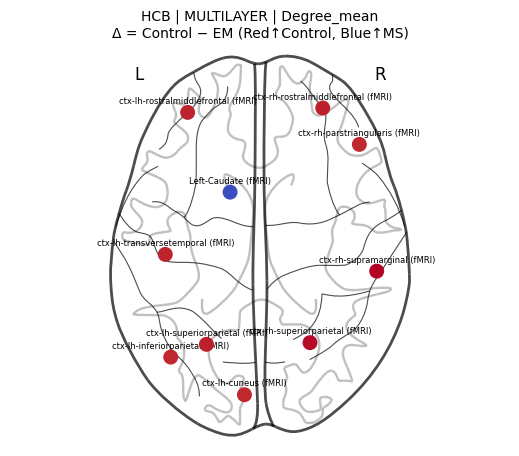

C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1728073723.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1728073723.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\1728073723.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\User

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn import plotting
from sklearn.preprocessing import MinMaxScaler
from matplotlib import cm
import os

# ----------------------------------------
# Example: Top 10 altered nodes in MULTILAYER | Degree_mean | HCB
# ----------------------------------------
subset = ranked_hcb[
    (ranked_hcb["Layer"] == "MULTILAYER") & 
    (ranked_hcb["Metric"] == "Degree_mean")
].sort_values("Abs_Delta", ascending=False).head(10)

node_ids = subset["Node"].astype(int).values
node_coords = coords_multilayer.iloc[node_ids][["X", "Y", "Z"]].values
delta_values = subset["Delta"].values

# Normalize delta for colors
norm_values = MinMaxScaler().fit_transform(delta_values.reshape(-1, 1)).flatten()
colors = cm.get_cmap("coolwarm")(norm_values)
adjacency = np.zeros((len(node_coords), len(node_coords)))

# Plot with brain background and labels
fig = plt.figure(figsize=(5, 4))
display = plotting.plot_connectome(
    adjacency_matrix=adjacency,
    node_coords=node_coords,
    node_color=colors,
    node_size=95,
    display_mode='z',
    figure=fig,
)

# Draw node labels over the map
ax = plt.gca()
node_labels = coords_multilayer.iloc[node_ids]["Label"].values.tolist()
for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
    ax.text(x, y + 3, label, fontsize=6, ha='center', va='bottom', color='black')

plt.title("HCB | MULTILAYER | Degree_mean\nΔ = Control − EM (Red↑Control, Blue↑MS)", fontsize=10)
plt.tight_layout()
plt.show()

# ----------------------------------------
# Define output folders for saving 2D figures
# ----------------------------------------
output_dir_hcb_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/2D"
output_dir_naples_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/figures/2D"

# Create directories if they don't exist
os.makedirs(output_dir_hcb_2d, exist_ok=True)
os.makedirs(output_dir_naples_2d, exist_ok=True)

# ----------------------------------------
# Function to generate and save top-view images per cohort/layer/metric
# ----------------------------------------
def save_topview_2d(df, cohort, output_dir):
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[
                (df["Layer"] == layer) & 
                (df["Metric"] == metric)
            ].sort_values("Abs_Delta", ascending=False).head(10)

            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values
            node_coords = coords_multilayer.iloc[node_ids][["X", "Y", "Z"]].values
            delta_values = subset["Delta"].values
            node_labels = coords_multilayer.iloc[node_ids]["Label"].values.tolist()

            norm_values = MinMaxScaler().fit_transform(delta_values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)
            adjacency = np.zeros((len(node_coords), len(node_coords)))

            fig = plt.figure(figsize=(5, 4))
            display = plotting.plot_connectome(
                adjacency_matrix=adjacency,
                node_coords=node_coords,
                node_color=colors,
                node_size=95,
                display_mode='z',
                figure=fig,
            )

            # Label nodes
            ax = plt.gca()
            for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
                ax.text(x, y + 3, label, fontsize=6, ha='center', va='bottom', color='black')

            plt.title(f"{cohort} | {layer} | {metric}\nΔ = Control − EM", fontsize=10)
            filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_topview.png"
            plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight', dpi=300)
            plt.close()

# ----------------------------------------
# Run function for both cohorts
# ----------------------------------------
save_topview_2d(ranked_hcb, "HCB", output_dir_hcb_2d)
save_topview_2d(ranked_naples, "Naples", output_dir_naples_2d)

### 🔄 Delta Computation and 2D Visualization of Nodal Differences (All nodes)

This section performs a full pipeline to compute and visualize group-level differences in nodal graph metrics:

1. **Compute Δ (Control − MS):**  
   For each node, metric, and layer, the mean difference between the control group and MS patients is calculated and stored as `Delta` (and `Abs_Delta` for ranking).

2. **Prepare Output Folders:**  
   Creates separate folders for HCB and Naples cohorts to store resulting 2D visualizations and data.

3. **Generate 2D Top-View Plots:**  
   For each cohort, connectivity layer, and metric:
   - Nodes are color-coded by Delta values (red = higher in controls, blue = higher in MS).
   - Nodes are displayed in axial (top) view with no edges.
   - One plot is generated per combination and saved as a PNG file.

4. **Export CSVs:**  
   Saves the computed Delta values into `.csv` files for further analysis or reporting.


In [6]:
# -------------------------------
# Step 1: Compute delta (Control − EM)
# -------------------------------
def compute_delta_from_summary(summary_long, cohort_name):
    summary_mean = summary_long[summary_long["Metric"].str.endswith("_mean")].copy()
    pivot = summary_mean.pivot_table(index=["Node", "Layer", "Metric"], columns="Group", values="Value").reset_index()
    pivot["Delta"] = pivot["Control"] - pivot["EM"]
    pivot["Abs_Delta"] = pivot["Delta"].abs()
    pivot["Cohort"] = cohort_name
    return pivot

delta_hcb = compute_delta_from_summary(summary_long_hcb, "HCB")
delta_naples = compute_delta_from_summary(summary_long_naples, "Naples")
delta_all = pd.concat([delta_hcb, delta_naples], ignore_index=True)

# -------------------------------
# Step 2: Output folders
# -------------------------------
output_dir_hcb_delta_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/Delta_2D"
output_dir_naples_delta_2d = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/figures/Delta_2D"

os.makedirs(output_dir_hcb_delta_2d, exist_ok=True)
os.makedirs(output_dir_naples_delta_2d, exist_ok=True)


# -------------------------------
# Step 3: Loop through layers/metrics and generate plots
# -------------------------------
for cohort in ["HCB", "Naples"]:
    df = delta_all[delta_all["Cohort"] == cohort]
    output_dir = output_dir_hcb_delta_2d if cohort == "HCB" else output_dir_naples_delta_2d
    
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[
                (df["Layer"] == layer) & 
                (df["Metric"] == metric)
            ]

            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values  # ⚠️ No -1 here for multilayer
            node_coords = coords_multilayer.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_multilayer.iloc[node_ids]["Label"].values.tolist()
            delta_values = subset["Delta"].values

            norm_values = MinMaxScaler().fit_transform(delta_values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)
            adjacency = np.zeros((len(node_coords), len(node_coords)))

            fig = plt.figure(figsize=(8, 6))
            display = plotting.plot_connectome(
                adjacency_matrix=adjacency,
                node_coords=node_coords,
                node_color=colors,
                node_size=120,
                display_mode='z',
                figure=fig,
            )

            # Añadir etiquetas encima de cada nodo
            ax = plt.gca()
            for (x, y, label) in zip(node_coords[:, 0], node_coords[:, 1], node_labels):
                ax.text(x, y + 3, label, fontsize=6, ha='center', va='bottom', color='black')

            plt.title(f"{cohort} | {layer} | {metric}\nΔ = Control − EM", fontsize=10)
            filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_delta_topview.png"
            plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight', dpi=300)
            plt.close()

# -------------------------------
# Step 4: Save deltas as CSV
# -------------------------------
delta_hcb.to_csv(os.path.join(output_dir_hcb_delta_2d, "nodal_deltas_by_group.csv"), index=False)   
delta_naples.to_csv(os.path.join(output_dir_naples_delta_2d, "nodal_deltas_by_group.csv"), index=False)

print("✅ CSVs saved:")
print(f"- HCB → {output_dir_hcb_delta_2d}")
print(f"- Naples → {output_dir_naples_delta_2d}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_512\508607953.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\508607953.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\508607953.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
C:\Users\a

✅ CSVs saved:
- HCB → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/Delta_2D
- Naples → F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/figures/Delta_2D


### 🧠 3D Interactive Visualization of Mean Nodal Differences (Delta) - All nodes

This section computes and visualizes the **mean group difference (Δ = Control − MS)** in nodal graph metrics across cohorts using **3D interactive plots**:

1. **Compute Delta (Control − MS):**  
   For each node, layer, and metric, the mean value in each group is used to calculate `Delta`. These results are stored per cohort (`HCB`, `Naples`).

2. **Generate 3D Views:**  
   For each combination of **cohort**, **connectivity layer**, and **graph metric**, an interactive brain view is created with:
   - Nodes plotted based on MNI coordinates.
   - Color-coded Δ values (Red = higher in controls, Blue = higher in MS).
   - No edges, focusing on node-level differences.

3. **Export as HTML:**  
   Each 3D visualization is saved as an `.html` file for easy navigation, sharing, or embedding into reports.

4. **Export CSVs:**  
   Delta values are also saved as `.csv` files for reference or additional analysis.

This pipeline provides an intuitive and interactive way to explore brain network alterations between control and MS groups at the nodal level.


In [7]:
# ----------------------------------------
# Compute mean deltas (Control − EM) per cohort
# ----------------------------------------
def compute_delta_for_3d(summary_long, cohort_name):
    df_mean = summary_long[summary_long["Metric"].str.endswith("_mean")].copy()
    pivot = df_mean.pivot_table(index=["Node", "Layer", "Metric"], columns="Group", values="Value").reset_index()
    pivot["Delta"] = pivot["Control"] - pivot["EM"]
    pivot["Cohort"] = cohort_name
    return pivot

delta_hcb_3d = compute_delta_for_3d(summary_long_hcb, "HCB")
delta_naples_3d = compute_delta_for_3d(summary_long_naples, "Naples")
delta_all_3d = pd.concat([delta_hcb_3d, delta_naples_3d], ignore_index=True)

# ----------------------------------------
# Create interactive 3D views for multilayer
# ----------------------------------------
views_3d_deltas = []

for cohort in ["HCB", "Naples"]:
    df = delta_all_3d[delta_all_3d["Cohort"] == cohort]
    for layer in df["Layer"].unique():
        for metric in df["Metric"].unique():
            subset = df[(df["Layer"] == layer) & (df["Metric"] == metric)]
            if subset.empty:
                continue

            node_ids = subset["Node"].astype(int).values  # ⚠️ No -1 for multilayer
            node_coords = coords_multilayer.iloc[node_ids][["X", "Y", "Z"]].values
            node_labels = coords_multilayer.iloc[node_ids]["Label"].values.tolist()
            norm_values = MinMaxScaler().fit_transform(subset["Delta"].values.reshape(-1, 1)).flatten()
            colors = cm.get_cmap("coolwarm")(norm_values)

            view = plotting.view_markers(
                node_coords,
                marker_color=colors,
                marker_size=6,
                marker_labels=node_labels,  # Optional: labels as tooltips
                title=f"{cohort} | {layer} | {metric}\nΔ = Control − EM (Red↑Control, Blue↑MS)"
            )
            views_3d_deltas.append((cohort, layer, metric, view))

# Open the first view as preview
views_3d_deltas[0][3].open_in_browser()

# ----------------------------------------
# Output directories for HTML files
# ----------------------------------------
output_dir_hcb_3d_delta = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA"
output_dir_naples_3d_delta = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA"

# Create folders if they don’t exist
os.makedirs(output_dir_hcb_3d_delta, exist_ok=True)
os.makedirs(output_dir_naples_3d_delta, exist_ok=True)

# ----------------------------------------
# Save all views as HTML
# ----------------------------------------
for cohort, layer, metric, view in views_3d_deltas:
    filename = f"{cohort}_{layer}_{metric.replace('/', '_')}_delta_3D.html"
    output_path = os.path.join(
        output_dir_hcb_3d_delta if cohort == "HCB" else output_dir_naples_3d_delta,
        filename
    )
    view.save_as_html(output_path)
    print(f"✅ Saved: {output_path}")

# ----------------------------------------
# Export CSV with node deltas
# ----------------------------------------
delta_hcb_3d.to_csv(os.path.join(output_dir_hcb_3d_delta, "nodal_deltas_by_group.csv"), index=False)
delta_naples_3d.to_csv(os.path.join(output_dir_naples_3d_delta, "nodal_deltas_by_group.csv"), index=False)

print("✅ CSVs saved:")
print(f"- HCB → {output_dir_hcb_3d_delta}")
print(f"- Naples → {output_dir_naples_3d_delta}")

C:\Users\alvar\AppData\Local\Temp\ipykernel_512\3628156689.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
f:\Cursos\UOC Master Bio Inf. Est\M0.209 - UOC - TFM - Bio ML - Grafos\venv\Lib\site-packages\nilearn\plotting\html_document.py:103: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn(
C:\Users\alvar\AppData\Local\Temp\ipykernel_512\3628156689.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("coolwarm")(norm_values)
f:\Cursos\UOC Master Bio Inf. Est\M0

✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA\HCB_MULTILAYER_Betweenness_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA\HCB_MULTILAYER_Closeness_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA\HCB_MULTILAYER_Degree_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA\HCB_MULTILAYER_Eigenvector_mean_delta_3D.html
✅ Saved: F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/nodal_summary_mlayer/figures/3D_DELTA\HCB_MULTILAYER_Strength_mean